In [1]:
import os
import shutil, subprocess, time
import pandas as pd
import numpy as np
import re
import mmap
from collections import defaultdict
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams
import ast
import random
from scipy import stats
from scipy.optimize import curve_fit
from scipy import special as sp
from scipy.integrate import quad
import math

/home/ivan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
os.chdir('/home/ivan/Desktop/Projects/K562 Over Expression Screens')

In [4]:
#build ref
subprocess.call('bowtie2-build -f ABL_WT_L298L.fa ABL'.split(' '))

Settings:
  Output files: "ABL.*.bt2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Max bucket size: default
  Max bucket size, sqrt multiplier: default
  Max bucket size, len divisor: 4
  Difference-cover sample period: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  ABL_WT_L298L.fa
Reading reference sizes
  Time reading reference sizes: 00:00:00
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:00
bmax according to bmaxDivN setting: 1693
Using parameters --bmax 1270 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these parameters: --bmax 1270 --dcv 1024
Constructing suffix-array element generator
Building DifferenceC

Building a SMALL index


0

In [3]:
Regions = ['64', '72', '121', '133', '147','219', '228', '244', '274', '290', '346', '458','466', '497', '505']
samples = []
for reg in Regions:
    for i in range(2):
        samples.append('-'.join([reg, 'Asc', str(i+1)]))
        samples.append('-'.join([reg, 'D0', str(i+1)]))

In [17]:
random.randint(1, 10_000_000)

7986119

In [73]:
for sample in samples:
    subprocess.call(['bowtie2', '--quiet', '--seed', '7986119', '--trim5', '20', '--trim3', '20', '-p', '20', '-q', '-x', 'ABL', '--1',
                     sample + '_R1_001.fastq.gz', '--2', sample + '_R2_001.fastq.gz', '--output', sample + '.txt'])

In [4]:
def MDZ_to_index(mdz_tag):
    mismatch_index = []
    curr_num = None
    for i in re.findall(r"\d+", mdz_tag):
        if curr_num != None:
            curr_num = curr_num + int(i) + 1
            mismatch_index.append(curr_num)
        if curr_num == None:
            curr_num = int(i)
            mismatch_index.append(int(i))
    return mismatch_index[:-1]

In [5]:
def read_to_index_mismatch(read):
    read_mismatch = []
    if read[2] != b'*': #aligned
        if read[5] != b'*': #good MAPQ
            if read[5][:-1] == read[18][5:]:
                read_mismatch.append('WT')
            if read[5][:-1] != read[18][5:]: #not WT
                if read[5][:-1].decode("utf-8") == str(len(read[9])): #no insertion or deltions, perfect alignment
                    mdz_index = MDZ_to_index(read[18][5:].decode("utf-8"))
                    seq = read[9].decode("utf-8")
                    read_start = int(read[3].decode("utf-8"))
                    for i in mdz_index:
                        read_mismatch.append([i + read_start, seq[i]])
    if read[5] == b'*':
        read_mismatch.append('LowMapQ')
    return read_mismatch

In [38]:
#put mismatches into a sample dictionary
read_agreement = defaultdict(list)

for sample in samples:
    with open(sample + '.txt', "r+") as f:
        start = time.time()
        # memory-map the file, size 0 means whole file
        mm = mmap.mmap(f.fileno(), 0)[:].splitlines()[3:]
        for read1, read2 in zip(mm, mm[1:]): #need to pairwise itteration to account for skipped reads because there are 
            read1_split = read1.split(b'\t')
            read2_split = read2.split(b'\t')
            if read1_split[0]==read2_split[0]: #confrim reads come from the same address
                read1_mismatches = read_to_index_mismatch(read1_split)
                read2_mismatches = read_to_index_mismatch(read2_split)
                if read1_mismatches == read2_mismatches:
                    read_agreement[sample].append([str([read1_split[3], read2_split[3]]), read1_mismatches])
                if read1_mismatches != read2_mismatches:
                    #is mismatches disagree, then look for overalp between reads
                    read_agreement[sample].append([str([read1_split[3], read2_split[3]]), [i for i in read1_mismatches if i in read2_mismatches]])
        print([sample , time.time() - start])

['64-Asc-1', 3.9779210090637207]
['64-D0-1', 1.8337597846984863]
['64-Asc-2', 3.2930548191070557]
['64-D0-2', 2.086651563644409]
['72-Asc-1', 2.764383554458618]
['72-D0-1', 2.1997270584106445]
['72-Asc-2', 3.7718958854675293]
['72-D0-2', 2.6472384929656982]
['121-Asc-1', 3.3432693481445312]
['121-D0-1', 3.3710808753967285]
['121-Asc-2', 2.6974782943725586]
['121-D0-2', 3.025543689727783]
['133-Asc-1', 2.8357467651367188]
['133-D0-1', 4.853395223617554]
['133-Asc-2', 2.7815537452697754]
['133-D0-2', 2.5871262550354004]
['147-Asc-1', 3.454051971435547]
['147-D0-1', 3.2141191959381104]
['147-Asc-2', 1.849782943725586]
['147-D0-2', 2.9082741737365723]
['219-Asc-1', 5.009700298309326]
['219-D0-1', 3.471785068511963]
['219-Asc-2', 3.420266628265381]
['219-D0-2', 2.9288949966430664]
['228-Asc-1', 2.7241861820220947]
['228-D0-1', 4.930194616317749]
['228-Asc-2', 2.529686212539673]
['228-D0-2', 2.6899800300598145]
['244-Asc-1', 2.8179991245269775]
['244-D0-1', 2.914480209350586]
['244-Asc-2', 6

In [39]:
#unpack mismatches based on read location and sample

screen_DF = pd.DataFrame(columns=['Mismatch', 'Count', 'Sample'])

for sample in samples:
    mismatch_count_DF = pd.DataFrame.from_dict(Counter([str(i) for i in read_agreement[sample]]), orient='index').reset_index()     
    mismatch_count_DF.columns = ['Start_Mismatch', 'Count']
    mismatch_count_DF['Sample'] = sample
    mismatch_count_DF['Start'] = mismatch_count_DF['Start_Mismatch'].apply(lambda x: ast.literal_eval(str(x))[0])
    mismatch_count_DF['Mismatch'] = mismatch_count_DF['Start_Mismatch'].apply(lambda x: str(ast.literal_eval(str(x))[1]))
    sample_start_mode = mismatch_count_DF.loc[(mismatch_count_DF['Count']>100), 'Start'].mode()
    print([sample, sample_start_mode])
    mismatch_count_DF2 = mismatch_count_DF.loc[mismatch_count_DF['Start']==sample_start_mode.values[0]] #use most frequent start position
    screen_DF = pd.concat([screen_DF, mismatch_count_DF2[['Mismatch', 'Count', 'Sample']]])

['64-Asc-1', 0    [b'153', b'153']
Name: Start, dtype: object]
['64-D0-1', 0    [b'161', b'161']
Name: Start, dtype: object]
['64-Asc-2', 0    [b'153', b'153']
Name: Start, dtype: object]
['64-D0-2', 0    [b'161', b'161']
Name: Start, dtype: object]
['72-Asc-1', 0    [b'153', b'153']
Name: Start, dtype: object]
['72-D0-1', 0    [b'161', b'161']
Name: Start, dtype: object]
['72-Asc-2', 0    [b'153', b'153']
Name: Start, dtype: object]
['72-D0-2', 0    [b'161', b'161']
Name: Start, dtype: object]
['121-Asc-1', 0    [b'345', b'345']
Name: Start, dtype: object]
['121-D0-1', 0    [b'349', b'349']
Name: Start, dtype: object]
['121-Asc-2', 0    [b'345', b'345']
Name: Start, dtype: object]
['121-D0-2', 0    [b'349', b'349']
Name: Start, dtype: object]
['133-Asc-1', 0    [b'334', b'334']
Name: Start, dtype: object]
['133-D0-1', 0    [b'343', b'343']
Name: Start, dtype: object]
['133-Asc-2', 0    [b'334', b'341']
Name: Start, dtype: object]
['133-D0-2', 0    [b'343', b'343']
Name: Start, dtype: 

In [40]:
screen_DF[['Sample', 'Count']].groupby('Sample').sum().to_csv('Sample_sums3.csv')

In [41]:
screen_DF.to_csv('Asc_Resistance_DMS250804.csv')

In [6]:
screen_DF = pd.read_csv('Asc_Resistance_DMS250721.csv')

In [7]:
#determine effect of mismatches as mutations

codon_dict = {'AAA' : 'K','AAC' : 'N','AAG' : 'K','AAT' : 'N','ACA' : 'T','ACC' : 'T','ACG' : 'T','ACT' : 'T','AGA' : 'R','AGC' : 'S','AGG' : 'R','AGT' : 'S','ATA' : 'I','ATC' : 'I','ATG' : 'M','ATT' : 'I','CAA' : 'Q','CAC' : 'H','CAG' : 'Q','CAT' : 'H','CCA' : 'P','CCC' : 'P','CCG' : 'P','CCT' : 'P','CGA' : 'R','CGC' : 'R','CGG' : 'R','CGT' : 'R','CTA' : 'L','CTC' : 'L','CTG' : 'L','CTT' : 'L','GAA' : 'E','GAC' : 'D','GAG' : 'E','GAT' : 'D','GCA' : 'A','GCC' : 'A','GCG' : 'A','GCT' : 'A','GGA' : 'G','GGC' : 'G','GGG' : 'G','GGT' : 'G','GTA' : 'V','GTC' : 'V','GTG' : 'V','GTT' : 'V','TAA' : 'O','TAC' : 'Y','TAG' : 'O','TAT' : 'Y','TCA' : 'S','TCC' : 'S','TCG' : 'S','TCT' : 'S','TGA' : 'O','TGC' : 'C','TGG' : 'W','TGT' : 'C','TTA' : 'L','TTC' : 'F','TTG' : 'L','TTT' : 'F'}

abl = 'gatgagtctccggggctctatgggtttctgaatgtcatcgtccactcagccactggatttaagcagagttcaAAAgcccttcagcggccagtagcatctgactttgagcctcagggtctgagtgaagccgctcgttggaactccaaggaaaaccttctcgctggacccagtgaaaatgaccccaaccttttcgttgcactgtatgattttgtggccagtggagataacactctaagcataactaaaggtgaaaagctccgggtcttaggctataatcacaatggggaatggtgtgaagcccaaaccaaaaatggccaaggctgggtcccaagcaactacatcacgccagtcaacagtctggagaaacactcctggtaccatgggcctgtgtcccgcaatgccgctgagtatctgctgagcagcgggatcaatggcagcttcttggtgcgtgagagtgagagcagtcctggccagaggtccatctcgctgagatacgaagggagggtgtaccattacaggatcaacactgcttctgatggcaagctctacgtctcctccgagagccgcttcaacaccctggccgagttggttcatcatcattcaacggtggccgacgggctcatcaccacgctccattatccagccccaaagcgcaacaagcccactgtctatggtgtgtcccccaactacgacaagtgggagatggaacgcacggacatcaccatgaagcacaagctgggcgggggccagtacgggGAGgtgtacgagggcgtgtggaagaaatacagcctgacggtggccgtgaagaccttgaaggaggacaccatggaggtggaagagttcttgaaagaagctgcagtcatgaaagagatcaaacaccctaacctggtgcagctccttggggtctgcacccgggagcccccgttctatatcatcACTgagttcatgacctacgggaacctcctggactacctgagggagtgcaaccggcaggaggtgaacgccgtggtgctgctgtacatggccactcagatctcgtcagccatggagtacctggagaagaaaaacttcatccacagagatcttgctgcccgaaactgcctggtaggggagaaccacttggtgaaggtagctgattttggcctgagcaggttgatgacaggggacacctacacagcccatgctggagccaagttccccatcaaatggactgcacccgagagcctggcctacaacaagttctccatcaagtccgacgtctgggcatttggagtattgctttgggaaattgctacctatggcatgtccccttacccgggaattgacctgtcccaggtgtatgagctgctagagaaggactaccgcatggagcgcccagaaggctgcccagagaaggtctatgaactcatgcgagcatgttggcagtggaatccctctgaccggccctcctttgctgaaatccaccaagcctttgaaacaatgttccaggaatccagtatctcagacgaagtggaaaaggagctggggaaacaaggcgtccgtggggctgtgagtaccttgctgcaggccccagagctgcccaccaagacgaggacctccaggagagctgcagagcacagagacaccactgacgtgcctgagatgcctcactccaagggccagggagagagcgatcctctggaccatgagcctgccgtgtctccattgctccctcgaaaagagcgaggtcccccggagggcggcctgaatgaagatgagcgccttctccccaaagacaaaaagaccaacttgttcagcgccttgatcaagaagaagaagaagacagccccaacccctcccaaacgcagcagctccttccgggagatggacggccagccggagcgcagaggggccggcgaggaagagggccgagacatcagcaacggggcactggctttcacccccttggacacagctgacccagccaagtccccaaagcccagcaatggggctggggtccccaatggagccctccgggagtccgggggctcaggcttccggtctccccacctgtggaagaagtccagcacgctgaccagcagccgcctagccaccggcgaggaggagggcggtggcagctccagcaagcgcttcctgcgctcttgctccgcctcctgcgttccccatggggccaaggacacggagtggaggtcagtcacgctgcctcgggacttgcagtccacgggaagacagtttgactcgtccacatttggagggcacaaaagtgagaagccggctctgcctcggaagagggcaggggagaacaggtctgaccaggtgacccgaggcacagtaacgcctccccccaggctggtgaaaaagaatgaggaagctgctgatgaggtcttcaaagacatcatggagtccagcccgggctccagcccgcccaacctgactccaaaacccctccggcggcaggtcaccgtggcccctgcctcgggcctcccccacaaggaagaagctggaaagggcagtgccttagggacccctgctgcagctgagccagtgacccccaccagcaaagcaggctcaggtgcaccagggggcaccagcaagggccccgccgaggagtccagagtgaggaggcacaagcactcctctgagtcgccagggagggacaaggggaaattgtccaggctcaaacctgccccgccgcccccaccagcagcctctgcagggaaggctggaggaaagccctcgcagagcccgagccaggaggcggccggggaggcagtcctgggcgcaaagacaaaagccacgagtctggttgatgctgtgaacagtgacgctgccaagcccagccagccgggagagggcctcaaaaagcccgtgctcccggccactccaaagccacagtccgccaagccgtcggggacccccatcagcccagcccccgttccctccacgttgccatcagcatcctcggccctggcaggggaccagccgtcttccaccgccttcatccctctcatatcaacccgagtgtctcttcggaaaacccgccagcctccagagcggatcgccagcggcgccatcaccaagggcgtggtcctggacagcaccgaggcgctgtgcctcgccatctctaggaactccgagcagatggccagccacagcgcagtgctggaggccggcaaaaacctctacacgttctgcgtgagctatgtggattccatccagcaaatgaggaacaagtttgccttccgagaggccatcaacaaactggagaataatctccgggagcttcagatctgcccggcgacagcaggcagtggtccagcggccactcaggacttcagcaagctcctcagttcggtgaaggaaatcagtgacatagtgcagaggtag'
WT_abl_codons = [''.join(abl)[i:i+3] for i in range(0, len(''.join(abl)), 3)]

AA_start = 3 #above abl seq starts in BCR, so the AA is not exactly abl

def mutation_effect(string_mut, abl=abl, AA_start=AA_start , WT_abl_codons=WT_abl_codons):
    if string_mut == "['WT']":
        return ['WT']
    if string_mut != "['WT']":
        mut_list = ast.literal_eval(string_mut)
        abl_copy = list(abl)
        for i, m in mut_list:
            abl_copy[i - 1] = m
        mut_abl_codons  = [''.join(abl_copy)[i:i+3] for i in range(0, len(''.join(abl_copy)), 3)]
        pred_mut_AA = [] 
        for i, (mut_cod, wt_cod) in enumerate(zip(mut_abl_codons, WT_abl_codons)):
            if mut_cod != wt_cod:
                pred_mut_AA.append(codon_dict[wt_cod.upper()] + str(i + AA_start) + codon_dict[mut_cod.upper()])
    return pred_mut_AA

In [8]:
def nuc_changes(string_mut):
    if string_mut == "['WT']":
        return ['WT']
    if string_mut != "['WT']":
        mut_list = ast.literal_eval(string_mut)
        abl_copy = list(abl)
        nuc_changes = []
        for i, m in mut_list:
            nuc_changes.append([abl_copy[i - 1].lower(), m.upper()])
            abl_copy[i - 1] = m
    return nuc_changes

In [9]:
def nuc_number(string_mut):
    if string_mut == "['WT']":
        return 0
    if string_mut != "['WT']":
        mut_list = ast.literal_eval(string_mut)
    return len(mut_list)

In [46]:
screen_DF.to_csv('Asc_Resistance_DMS25.csv')

In [8]:
screen_DF = pd.read_csv('Asc_Resistance_DMS25.csv')

In [9]:
screen_DF['Cond_Rep'] = screen_DF['Sample'].str.split('-').str[1] + '_' + screen_DF['Sample'].str.split('-').str[2] 

In [10]:
screen_DF

,Unnamed: 0,Mismatch,Count,Sample,Cond_Rep
0,0,"[[199, 'G'], [200, 'A'], [201, 'C']]",3142,64-Asc-1,Asc_1
1,1,"[[205, 'A'], [206, 'G'], [207, 'C']]",3687,64-Asc-1,Asc_1
2,2,"[[193, 'A'], [194, 'A'], [195, 'G']]",3328,64-Asc-1,Asc_1
3,3,"[[193, 'A'], [194, 'G'], [195, 'C']]",2163,64-Asc-1,Asc_1
4,5,"[[196, 'C'], [197, 'T'], [198, 'G']]",1268,64-Asc-1,Asc_1
...,...,...,...,...,...
347485,6069,"[[1442, 'A'], [1529, 'T'], [1530, 'C']]",1,505-D0-2,D0_2
347486,6070,"[[1507, 'C'], [1509, 'G'], [1525, 'A'], [1526,...",1,505-D0-2,D0_2
347487,6072,"[[1505, 'G'], [1513, 'C'], [1515, 'G']]",1,505-D0-2,D0_2
347488,6073,"[[1478, 'T'], [1486, 'T'], [1525, 'A'], [1526,...",1,505-D0-2,D0_2


In [11]:
Regions = ['64-', '72-', '121', '133', '147', '219', '228', '244', '274', '290', '346', '458', '466', '497', '505']
min_count = 3
threshold = (1/4000)


Asc_DMS_Replicates = pd.DataFrame()
Asc_DMS = pd.DataFrame()
Supplementary = pd.DataFrame()

for reg in Regions:
    screen_reg = screen_DF.loc[screen_DF['Sample'].str[:3]==reg].reset_index()
    screen_reg['Cond_Rep'] = screen_reg['Sample'].str.split('-').str[1] + '_' + screen_reg['Sample'].str.split('-').str[2]
    screen_reg2 = screen_reg.loc[screen_reg['Count'] > min_count] #minimum count 
    screen_reg_conds = screen_reg['Cond_Rep'].drop_duplicates()[~screen_reg['Cond_Rep'].drop_duplicates().str.contains('D0')].to_list()
    PV =  pd.pivot_table(screen_reg2, index='Mismatch', columns='Cond_Rep', values='Count').fillna(0).sort_values('D0_1', ascending=False)
    Norm = PV.divide(PV.sum(axis=0))
    Norm2 = Norm.loc[(Norm['D0_1'] > threshold) & (Norm['D0_2'] > threshold)] #filter out low freqeuncy mutations
    for cond in screen_reg_conds:
        Norm2[cond+'_FC'] = Norm2[cond].div(Norm2[['D0_1','D0_2']].mean(axis=1))
    Norm2['Mut'] = Norm2.index.map(mutation_effect)
    Norm2['Nuc_mut'] = Norm2.index.map(nuc_changes)
    Norm2['Nuc_len'] = Norm2.index.map(nuc_number)
    Norm2['Mut_len'] = Norm2['Mut'].map(len)
    Norm2['Asc_FC'] = Norm2[Norm2.columns[(Norm2.columns.str.contains('FC')) & (Norm2.columns.str.contains('Asc'))]].mean(axis=1)
    Norm2['Base_Freq'] = Norm2[['D0_1','D0_2']].mean(axis=1)
    Norm2['Region'] = reg
    Asc_DMS_Replicates = pd.concat([Asc_DMS_Replicates,Norm2[['Region', 'Mut', 'Nuc_mut', 'Nuc_len', 'Mut_len', 'Base_Freq','Asc_1_FC', 'Asc_2_FC']]], ignore_index=True)
    
    counts_Norm2 = pd.merge(PV, Norm2, left_index=True, right_index=True, how='right',  suffixes=('_count', '_norm'))
    Supplementary = pd.concat([Supplementary, counts_Norm2])
    
    Norm3 = Norm2.loc[(Norm2['Mut_len']<2), ['Region','Mut', 'Mut_len','Base_Freq', 'Asc_FC']]
    Asc_DMS = pd.concat([Asc_DMS,Norm3], ignore_index=True)

/tmp/ipykernel_74328/3682568701.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Norm2[cond+'_FC'] = Norm2[cond].div(Norm2[['D0_1','D0_2']].mean(axis=1))
/tmp/ipykernel_74328/3682568701.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Norm2[cond+'_FC'] = Norm2[cond].div(Norm2[['D0_1','D0_2']].mean(axis=1))
/tmp/ipykernel_74328/3682568701.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [12]:
screen_reg.loc[screen_reg['Count'] > min_count]

,index,Unnamed: 0,Mismatch,Count,Sample,Cond_Rep
0,335578,1,"[[1510, 'A']]",8583,505-Asc-1,Asc_1
2,335580,3,"[[1522, 'G'], [1523, 'G'], [1524, 'C']]",4659,505-Asc-1,Asc_1
3,335581,4,"[[1522, 'A'], [1523, 'A'], [1524, 'C']]",1439,505-Asc-1,Asc_1
4,335582,5,"[[1510, 'T'], [1511, 'A'], [1512, 'C'], [1525,...",1841,505-Asc-1,Asc_1
5,335583,6,"[[1513, 'C'], [1515, 'C']]",1548,505-Asc-1,Asc_1
...,...,...,...,...,...,...
18142,353720,5144,"[[1507, 'A'], [1508, 'T'], [1509, 'C'], [1528,...",4,505-D0-2,D0_2
18194,353772,5206,"[[1441, 'A'], [1520, 'C'], [1521, 'C']]",4,505-D0-2,D0_2
18425,354003,5513,"[[1513, 'A'], [1515, 'G'], [1526, 'A']]",6,505-D0-2,D0_2
18477,354055,5583,"[[1517, 'T'], [1518, 'C'], [1528, 'C'], [1530,...",4,505-D0-2,D0_2


In [22]:
Supplementary.to_csv('Supplementary_File2.csv')

In [13]:
Asc_DMS_Replicates

Cond_Rep,Region,Mut,Nuc_mut,Nuc_len,Mut_len,Base_Freq,Asc_1_FC,Asc_2_FC
0,64-,[L65A],"[[c, G], [t, C], [t, C]]",3,1,0.030930,0.132590,0.127029
1,64-,[F66H],"[[t, C], [t, A]]",2,1,0.023906,0.290114,0.232874
2,64-,[F66A],"[[t, G], [t, C]]",2,1,0.023777,0.625811,0.558415
3,64-,[Y70H],"[[t, C], [t, C]]",2,1,0.017463,0.103607,0.113555
4,64-,[L65Q],"[[t, A], [t, G]]",2,1,0.019962,0.222465,0.233841
...,...,...,...,...,...,...,...,...
2769,505,"[L510L, G511H]","[[g, T], [g, C], [g, A], [g, C]]",4,2,0.000715,0.294406,0.366720
2770,505,[K512T],"[[a, C], [a, C]]",2,1,0.000581,0.161841,0.225594
2771,505,[E505G],"[[a, G], [a, C]]",2,1,0.000359,4.213147,5.064488
2772,505,[E509N],"[[g, A], [g, C]]",2,1,0.000477,2.452086,1.705073


In [14]:
#Growth Rates from Screen
growth_rate_dict = {'133' : 0.0268737835083204, '244' : 0.0213707020463313, '466' : 0.0264956979829883, 
                    '505' : 0.0272049185591388, '64-' : 0.0265101775658025, '72-' : 0.0243621787381701,
                    '274' : 0.0189660233214211, '290' : 0.0191694550570057, '346' : 0.016868160003703, 
                    '497' : 0.0272055600419509, '128' : 0.0220072786345605, '219' : 0.0258520400060282, 
                    '228' : 0.02378437702654 , '121' : 0.0265343056450463, '147' : 0.0179762493611919,
                    '458' : 0.0270739372268026 }

Basic exponential growth formula using individual mutant counts (N)

$$N = N_0 e^{rt}$$

Exponential growth formula of individual mutant based on screen counts

$$\ln\left(\frac{N_2}{N_1} \cdot e^{r_2 t}\right) / t = r_1$$

$$\frac{\ln(N_2 / N_1)}{t} + r_2 = r_1$$

r1 = growth rate of mutation, r2 = growth rate of population

In [15]:
#convert Fold Change to Growth Rates
Asc_DMS_Replicates['Rep1'] = (np.log(Asc_DMS_Replicates['Asc_1_FC'])/(24*9)) + Asc_DMS_Replicates['Region'].map(growth_rate_dict)
Asc_DMS_Replicates['Rep2'] = (np.log(Asc_DMS_Replicates['Asc_2_FC'])/(24*9)) + Asc_DMS_Replicates['Region'].map(growth_rate_dict)
#drop infinites due to zero count
Asc_DMS_Replicates = Asc_DMS_Replicates.loc[(Asc_DMS_Replicates['Rep1'] > -100) & (Asc_DMS_Replicates['Rep2'] > -100)]

#Min_Max Normlization
for reg in Regions:
    for rep in ['Rep1', 'Rep2']:
        min_gr = Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region']==reg, rep].quantile(q=0.01)
        max_gr = Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region']==reg, rep].quantile(q=0.99)
        Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region']==reg, rep + '_Norm'] = ((Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region']==reg, rep] - min_gr)/(max_gr - min_gr))*100


/home/ivan/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ivan/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_74328/3589133511.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region']==reg, rep + '_Norm'] = ((Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region']==reg, rep] - min_gr)/(max_gr - min_gr))*100
/tmp/ipykernel_74328/3589133511.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [17]:
Asc_DMS_Replicates = Asc_DMS_Replicates.loc[(Asc_DMS_Replicates['Mut_len']==1) & (Asc_DMS_Replicates['Nuc_len']>0) & (Asc_DMS_Replicates['Base_Freq'] > (1/4000))]
Asc_DMS_Replicates.to_csv('Asc_DMS_Replicates25_1AA.csv')

In [18]:
Asc_DMS_Replicates = Asc_DMS_Replicates.loc[(Asc_DMS_Replicates['Mut_len'] < 2) & (Asc_DMS_Replicates['Base_Freq'] > (1/4000))]

In [20]:
#replicate correlation by region
for reg in Regions:
    print([reg, stats.pearsonr(Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region'] == reg, 'Rep1_Norm'],
                  Asc_DMS_Replicates.loc[Asc_DMS_Replicates['Region'] == reg, 'Rep2_Norm'])])

['64-', PearsonRResult(statistic=0.9612136965102838, pvalue=4.007987982416279e-84)]
['72-', PearsonRResult(statistic=0.8816977856960991, pvalue=1.5604703398474577e-46)]
['121', PearsonRResult(statistic=0.9600799635145619, pvalue=3.1456399067820222e-78)]
['133', PearsonRResult(statistic=0.9424450803446106, pvalue=7.991234657893989e-72)]
['147', PearsonRResult(statistic=0.8519138424972837, pvalue=3.8814395891304416e-43)]
['219', PearsonRResult(statistic=0.9628056275703983, pvalue=8.433097228688004e-44)]
['228', PearsonRResult(statistic=0.9387403896005235, pvalue=9.51029319965746e-72)]
['244', PearsonRResult(statistic=0.9464900070102475, pvalue=4.2302026983268e-73)]
['274', PearsonRResult(statistic=0.8838052703829131, pvalue=1.1578206975531245e-53)]
['290', PearsonRResult(statistic=0.8887699580800348, pvalue=1.0056698256650714e-54)]
['346', PearsonRResult(statistic=0.8798788113585643, pvalue=5.623702917671698e-51)]
['458', PearsonRResult(statistic=0.9611937918364117, pvalue=4.942048931795

In [21]:
stats.pearsonr(Asc_DMS_Replicates['Rep1_Norm'], Asc_DMS_Replicates['Rep2_Norm'])

PearsonRResult(statistic=0.9182711322101133, pvalue=0.0)

Overall replicate correlation is 0.92

In [22]:
sns.set_context("notebook")
plt.rcParams['font.family'] = 'Arial'

In [26]:
# --- 1. PUBLICATION PARAMETERS ---
plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': 1,
    'pdf.fonttype': 42})

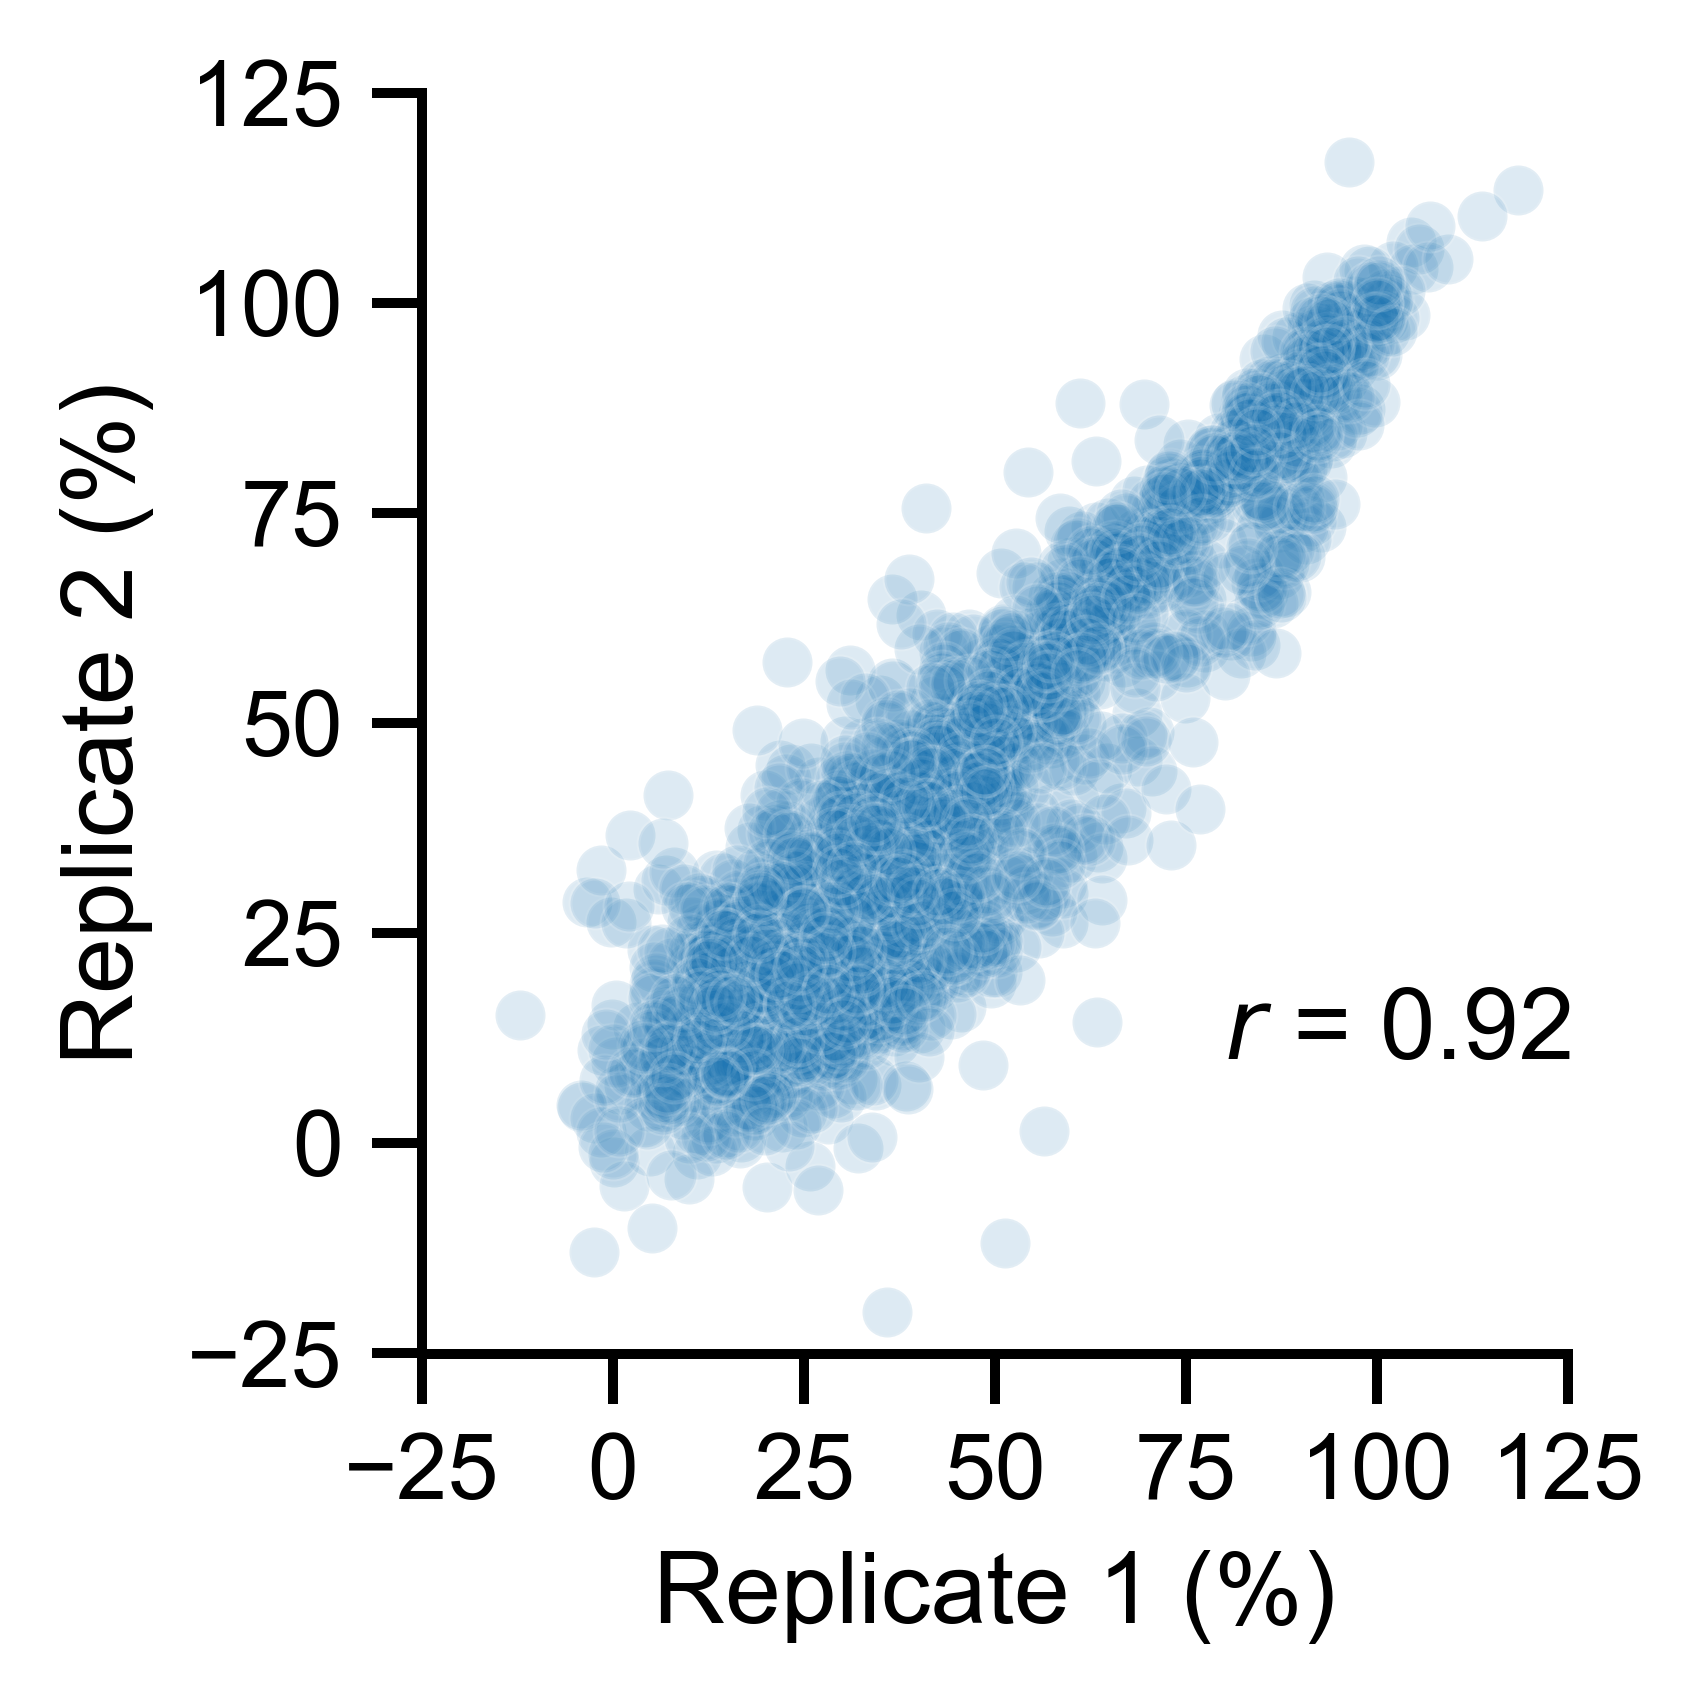

In [30]:
rcParams['figure.figsize'] = 3,3
plt.rcParams['axes.linewidth'] = 1.2
plt.tick_params(axis='both', width=1.2)
reps = sns.scatterplot(x='Rep1_Norm', y='Rep2_Norm', alpha=0.15, data=Asc_DMS_Replicates)
reps.set_yticks([-25, 0,25,50,75,100,125])
reps.set_xticks([-25, 0,25,50,75,100,125])
reps.set(xlabel = 'Replicate 1 (%)', ylabel='Replicate 2 (%)', xlim=[-25,125], ylim=[-25,125])
reps.text(80, 10,'$r$ = 0.92') 
sns.despine()
plt.tight_layout()
reps.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/DMS Screen/DMS Asc Screen Replicate Correlationv4.pdf", dpi=800, transparent=True)

In [31]:
#convert list of list of mutants to list of mut strings

mut_list = []

for mut in Asc_DMS['Mut'].tolist():
    list_to_mut = ast.literal_eval(str(mut))
    if list_to_mut == []:
        mut_list.append('?') #Forward & Reverse read do not agree
    elif list_to_mut == ['WT']:
        mut_list.append('WT') #Forward & Reverse reads are WT sequence
    else:
        mut_list.append(list_to_mut[0])

Asc_DMS['Mut'] = mut_list

In [32]:
#convert Fold Change to Growth Rates
Asc_DMS['r'] = (np.log(Asc_DMS['Asc_FC'])/(24*9)) + Asc_DMS['Region'].map(growth_rate_dict)
#filter for only single AA mutations and WT
Asc_DMS = Asc_DMS.loc[(Asc_DMS['Mut_len']==1) & (Asc_DMS['r']>-100)]

for reg in Regions:
    #Min_Max Normlization
    min_gr = Asc_DMS.loc[Asc_DMS['Region']==reg, 'r'].quantile(q=0.01)
    max_gr = Asc_DMS.loc[Asc_DMS['Region']==reg, 'r'].quantile(q=0.99)
    Asc_DMS.loc[Asc_DMS['Region']==reg, 'Min_Max'] = ((Asc_DMS.loc[Asc_DMS['Region']==reg, 'r'] - min_gr)/(max_gr - min_gr))*100

In [34]:
#I314T is removed because it has counts less than the min number of counts (3)
Asc_DMS2 = Asc_DMS.loc[(Asc_DMS['Mut_len']==1) & (Asc_DMS['Mut']!='WT') & (Asc_DMS['Mut']!='I314T')]
Asc_DMS2['Start'] = Asc_DMS2['Mut'].str[0]
Asc_DMS2['Mutation'] = Asc_DMS2['Mut'].str[-1]
Asc_DMS2['Position'] = Asc_DMS2['Mut'].str[1:-1].astype(int)
Asc_DMS2 = Asc_DMS2.sort_values('Base_Freq', ascending=False).drop_duplicates(subset='Mut', keep='first') #keep the higher confidence measurment

/tmp/ipykernel_74328/1708749418.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Asc_DMS2['Start'] = Asc_DMS2['Mut'].str[0]
/tmp/ipykernel_74328/1708749418.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Asc_DMS2['Mutation'] = Asc_DMS2['Mut'].str[-1]
/tmp/ipykernel_74328/1708749418.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [35]:
#Range of minimum growth rate per region
[Asc_DMS2.groupby('Region')['r'].min().min(), Asc_DMS2.groupby('Region')['r'].min().max()]

[0.0062773762834777945, 0.01966002175758598]

In [36]:
#Range of maximum growth rates per region
[Asc_DMS2.groupby('Region')['r'].max().min(), Asc_DMS2.groupby('Region')['r'].max().max()]

[0.02700185628146572, 0.03721422827886961]

In [37]:
Asc_DMS2.sort_values('Min_Max', ascending=False).to_csv('Asc_DMS2.csv')

Skewed Gaussian Function

$$f(x) = a \left( \frac{1}{(\sigma_g \sqrt{2\pi})} \right) \exp \left( -\frac{(x - \mu)^2}{(2 \sigma_g^2)} \right) \left( 0.5 \left( 1 + \text{erf} \left( \alpha \frac{(x - \mu)}{(\sigma_g \sqrt{2})} \right) \right) \right)$$

In [38]:
#https://stackoverflow.com/questions/47971394/define-skewed-gaussian-function-that-returns-two-parameters-after-fitting
def skew(x, sigmag, mu, alpha, a):
    normpdf = (1 / (sigmag * np.sqrt(2 * math.pi))) * np.exp(-(np.power((x - mu), 2) / (2 * np.power(sigmag, 2))))
    normcdf = (0.5 * (1 + sp.erf((alpha * ((x - mu) / sigmag)) / (np.sqrt(2)))))
    return a * normpdf * normcdf

def two_skewed_guassians(x, sigmag1, mu1, alpha1, a1, sigmag2, mu2, alpha2, a2):
    return skew(x, sigmag1, mu1, alpha1, a1) + skew(x, sigmag2, mu2, alpha2, a2)


In [40]:
#define bins
n_bins =40
DMS_bins = Asc_DMS2.loc[Asc_DMS2['Min_Max']>-100, 'Min_Max'].value_counts(bins=n_bins).reset_index()
DMS_bins['X'] = DMS_bins['index'].apply(lambda x: x.mid)

#fit two skewed gussians over the data
popt, pcov = curve_fit(two_skewed_guassians, DMS_bins['X'], DMS_bins['count'], 
                       p0=(15,10,0.5,4000,10,85,1,2500), maxfev = 10000,
                     bounds=((0,0,0,0,0,0,0,0) ,(np.inf,50,np.inf,np.inf,np.inf,100,np.inf,np.inf)))

#fit lines
gr_space= np.linspace(-20,120,400)
y_fit = two_skewed_guassians(gr_space, *popt)
left_gussain = skew(gr_space, *popt[:4])
right_gussain = skew(gr_space, *popt[4:])
print(popt[:4])
print(popt[4:])

[3.54767374e+01 1.62080563e+00 1.38252001e+01 1.17547743e+04]
[1.18114463e+01 8.53173284e+01 3.68513354e-04 2.38215366e+03]


In [41]:
SD2 = popt[0]*2 + popt[1]

In [42]:
SD2

72.5742804995485

Two standard deviation from the null distirbution is also about 73

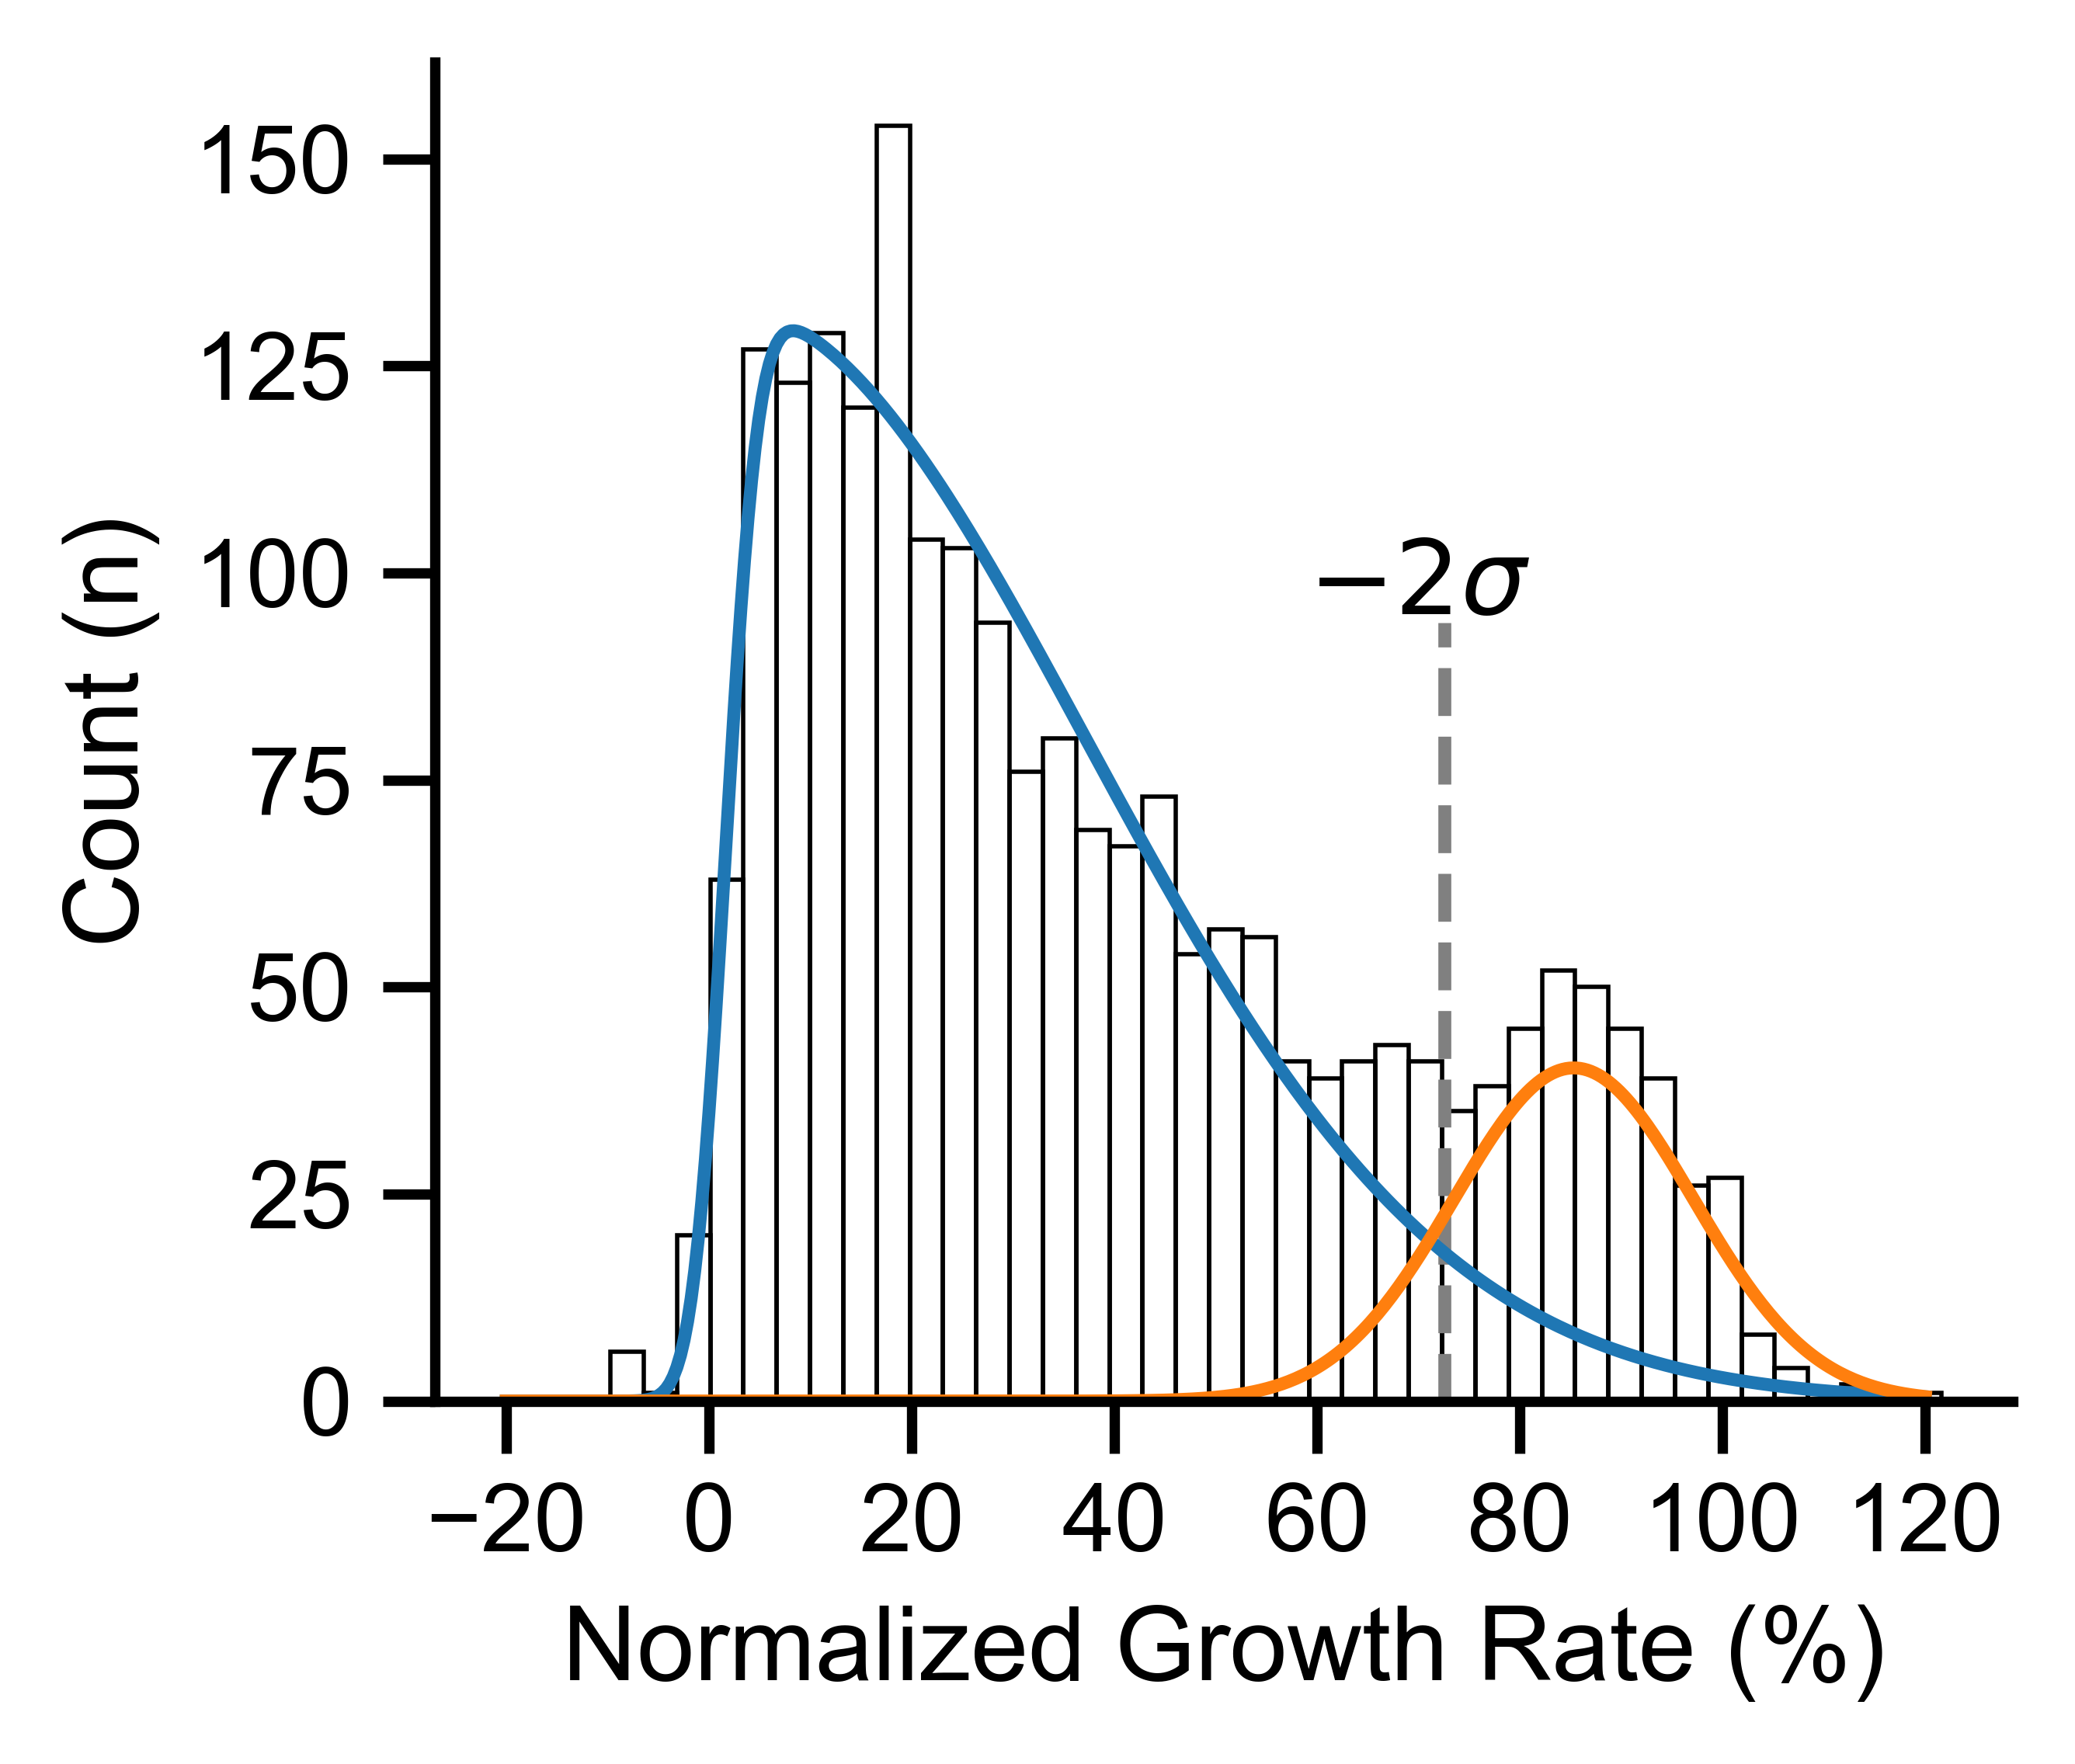

In [50]:
plt.figure(figsize=(3.5,3), dpi=800)
plt.rcParams['axes.linewidth'] = 1.2
plt.tick_params(axis='both', width=1.2)
hist_gr = sns.histplot(x='Min_Max', data=Asc_DMS2, bins=n_bins, color='black', fill=False,  edgecolor='red')
hist_gr.set(xlabel='Normalized Growth Rate (%)', ylabel='Count (n)')
hist_gr.text(SD2-2.5, 95, '$\it{-2 σ}$', ha='center')
plt.vlines(SD2, 0,94, linestyles="--", color='grey')
sns.lineplot(x=gr_space, y=left_gussain)
sns.lineplot(x=gr_space, y=right_gussain)
hist_gr.set_xticks([-20,0,20,40,60,80, 100, 120])
sns.despine(right=True, top=True)
plt.tight_layout()
hist_gr.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/DMS Screen/DMS Asc 2Guass Distribution 260119.pdf",transparent=True) 

In [61]:
Asc_WT_positions = Asc_DMS2.copy()
Asc_WT_positions['Mutation'] = Asc_WT_positions['Start']
Asc_WT_positions['Min_Max'] = np.nan
Asc_WT_positions = Asc_WT_positions[['Region', 'Min_Max', 'Start', 'Mutation', 'Position']].drop_duplicates()
Asc_WT_positions['Mark'] = 1

In [62]:
Asc_DMS2['Mark'] = 0
Asc_DMS3 = pd.concat([Asc_DMS2[['Region', 'Min_Max', 'Start', 'Mutation', 'Position', 'Mark']], Asc_WT_positions], ignore_index=False)

In [63]:
#Filter out low coverage positions
Position_Coverage = (Asc_DMS3['Position'].value_counts() > 5).reset_index()
Position_Coverage = Position_Coverage.loc[Position_Coverage['count'] == True, 'Position'].values

Asc_DMS3 = Asc_DMS3.loc[Asc_DMS3['Position'].isin(Position_Coverage)]
#Asc_DMS3 = Asc_DMS3.sort_values('Position')

In [64]:
known_resistance_mutants = ['I502L', 'V468F', 'P465S', 'M351T', 'K294E', 'M244V', 'L248V']
Asc_DMS2.loc[Asc_DMS2 ['Min_Max'] > 80, 'Mut'].count() - len(known_resistance_mutants) - len(['Y139D'])

279

In [65]:
Asc_DMS2.loc[Asc_DMS2['Mut'].isin(known_resistance_mutants+['Y139D']), ['Mut', 'Min_Max']]

Cond_Rep,Mut,Min_Max
996,L248V,98.085260
1460,M351T,101.361372
1962,I502L,82.878528
1346,K294E,85.791570
1651,P465S,90.453168
545,Y139D,83.260171
1039,M244V,94.410510
1879,V468F,100.284810


In [83]:
Asc_DMS3.loc[Asc_DMS3['Position']==277]

Cond_Rep,Region,Min_Max,Start,Mutation,Position,Mark
1123,274,22.649596,T,C,277,0
1131,274,6.441701,T,L,277,0
1139,274,20.879647,T,W,277,0
1132,274,70.838592,T,A,277,0
1168,274,4.345639,T,P,277,0
1159,274,9.266455,T,V,277,0
1170,274,102.962369,T,E,277,0
1173,274,9.649847,T,D,277,0
1182,274,7.200973,T,G,277,0
1199,274,73.724177,T,N,277,0


Known resistance mutations are above 80% min-max normalized growth rate.

In [66]:
spacer_col = [64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77, 78,  79, 80,
              121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
              144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 156,
              219, 220, 221, 222, 223,
              228, 229, 230, 231, 232, 233, 234, 235, 236, 
              242, 243, 244, 245, 246, 247, 248, 249, 250, 
              274, 275, 276, 277, 278, 279, 280, 281, 282,
              290, 291, 292, 293, 294, 295, 296, 297,298, 
              346, 347, 348, 349, 350, 351, 352, 353, 354, 
              458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474,
              497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512]

In [67]:
spacer_col_kinase = [242, 243, 244, 245, 246, 247, 248, 249, 250, 
              274, 275, 276, 277, 278, 279, 280, 281, 282,
              290, 291, 292, 293, 294, 295, 296, 297,298, 
              346, 347, 348, 349, 350, 351, 352, 353, 354, 
              458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474,
              497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512]

In [68]:
spacer_col_SH3SH2 = [64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77, 78,  79, 80,
              121, 122, 123, 124, 125, 126, 127, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
             147, 148, 149, 150, 151, 152, 153, 154, 156,
              219, 220, 221, 222, 223,
              228, 229, 230, 231, 232, 233, 234, 235]

In [69]:
Ivan_AA_order = ['K', 'R', 'D', 'E', 'C', 'M', 'N', 'Q', 'S', 'T',
           'A', 'I', 'L', 'V', 'F', 'H', 'W', 'Y','G', 'P']

Asc_DMS_PV = pd.pivot_table(Asc_DMS3,  index='Mutation', columns='Position', values='Min_Max').replace(pd.NA,'')
Asc_WT_PV = pd.pivot_table(Asc_WT_positions,  index='Mutation', columns='Position', values='Mark').replace(pd.NA, '')
Asc_DMS_PV = Asc_DMS_PV.reindex(index=Ivan_AA_order, columns=spacer_col)
Asc_WT_PV = Asc_WT_PV.reindex(index=Ivan_AA_order, columns=spacer_col)[Asc_DMS_PV.columns]

In [70]:
Ivan_AA_order = ['K', 'R', 'D', 'E', 'C', 'M', 'N', 'Q', 'S', 'T',
           'A', 'I', 'L', 'V', 'F', 'H', 'W', 'Y','G', 'P']
#split data based on domains
Asc_DMS3_SH3SH2 = Asc_DMS3.loc[Asc_DMS3['Position'].between(64, 235)]
Asc_DMS3_kinase = Asc_DMS3.loc[Asc_DMS3['Position']>235]
Asc_WT_positions_SH3SH2 = Asc_WT_positions.loc[Asc_WT_positions['Position'].between(64, 235)]
Asc_WT_positions_kinase = Asc_WT_positions.loc[Asc_WT_positions['Position']>235]

Asc_DMS_PV_SHSH2 = pd.pivot_table(Asc_DMS3_SH3SH2,  index='Mutation', columns='Position', values='Min_Max').replace(pd.NA,'')
Asc_WT_PV_SHSH2  = pd.pivot_table(Asc_WT_positions_SH3SH2,  index='Mutation', columns='Position', values='Mark').replace(pd.NA, '')
Asc_DMS_PV_SHSH2  = Asc_DMS_PV_SHSH2 .reindex(index=Ivan_AA_order, columns=spacer_col_SH3SH2)
Asc_WT_PV_SHSH2  = Asc_WT_PV_SHSH2 .reindex(index=Ivan_AA_order, columns=spacer_col_SH3SH2)[Asc_DMS_PV_SHSH2.columns]

Asc_DMS_PV_kinase = pd.pivot_table(Asc_DMS3_kinase,  index='Mutation', columns='Position', values='Min_Max').replace(pd.NA,'')
Asc_WT_PV_kinase  = pd.pivot_table(Asc_WT_positions_kinase,  index='Mutation', columns='Position', values='Mark').replace(pd.NA, '')
Asc_DMS_PV_kinase  = Asc_DMS_PV_kinase.reindex(index=Ivan_AA_order, columns=spacer_col_kinase)
Asc_WT_PV_kinase  = Asc_WT_PV_kinase.reindex(index=Ivan_AA_order, columns=spacer_col_kinase)[Asc_DMS_PV_kinase.columns]

In [80]:
Asc_DMS_PV

Position,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,144,145,146,147,148,149,150,151,152,153,154,156,219,220,221,222,223,228,229,230,231,232,233,234,235,236,242,243,244,245,246,247,248,249,250,274,275,276,277,278,279,280,281,282,290,291,292,293,294,295,296,297,298,346,347,348,349,350,351,352,353,354,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512
Mutation,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
K,44.471963,20.206475,75.328192,87.502189,98.155924,65.836325,82.873127,58.636437,43.050493,NaN,78.669547,21.563519,97.647136,68.632546,50.330348,52.990681,NaN,88.543371,59.455630,11.630627,NaN,72.011598,72.309621,79.306163,NaN,NaN,NaN,NaN,NaN,91.493725,26.738193,97.672603,34.480536,16.212292,102.327397,95.946695,37.434714,NaN,NaN,NaN,NaN,82.910543,24.916521,40.714827,49.899781,43.833166,33.333310,92.185393,21.039037,NaN,NaN,14.321522,43.325499,NaN,NaN,63.720924,81.302271,89.378786,46.790343,48.575437,12.508767,NaN,12.753884,NaN,18.531276,58.661894,21.392686,NaN,53.566294,NaN,NaN,28.616694,NaN,NaN,43.776965,37.796773,68.774492,3.428927,70.983581,18.031133,34.170432,NaN,-0.286019,NaN,40.853356,6.721126,NaN,8.287804,17.055680,14.982666,NaN,45.482478,14.369048,24.199717,44.028261,13.162205,18.078705,17.049417,10.706449,NaN,10.725580,77.677531,18.966067,95.239118,77.581842,77.156331,-0.341948,91.641150,21.185806,NaN,96.576771,25.145185,25.073507,77.865827,10.521829,18.802208,NaN,96.215119,34.904063,20.783332,62.091296,80.604724,86.237066,4.442077,86.952983,89.196344,91.864898,19.175463,NaN,79.238508,86.612068,25.901389,NaN
R,38.272848,22.931086,57.286425,94.356970,101.280062,86.641910,81.732748,65.385352,16.392849,36.266363,NaN,3.783480,104.017148,66.417169,60.516587,40.235517,NaN,86.915662,86.249021,34.255603,18.926029,61.511945,71.719253,NaN,NaN,NaN,NaN,NaN,NaN,82.652370,NaN,89.841028,86.458386,24.149808,106.282489,97.654929,40.114551,NaN,NaN,NaN,NaN,88.734555,22.927878,38.425017,31.955948,43.557081,NaN,78.746760,38.900511,NaN,19.253976,NaN,32.130541,28.895409,NaN,48.603873,64.831836,93.534705,58.169332,31.624907,13.396781,24.640120,10.946823,NaN,22.786616,67.333197,26.913512,53.588070,52.564242,52.754522,26.027270,20.305133,NaN,42.168933,51.120668,41.754860,98.678170,5.340089,72.792534,4.398036,46.845097,NaN,7.306687,3.400646,33.822776,6.751368,10.923230,6.343876,5.808020,11.908412,NaN,25.358920,14.705461,44.830436,69.804998,7.841121,3.698809,23.176471,15.661982,NaN,5.561402,77.169558,11.148749,113.950131,59.976082,64.373508,2.229832,94.463006,26.069424,26.434510,109.737096,72.439430,27.202959,75.013754,1.587330,NaN,NaN,89.009524,29.987211,24.678967,36.147261,79.103963,85.075707,17.694942,73.156842,86.144345,98.621220,23.069225,10.897216,93.587830,83.720753,NaN,1.629247
D,26.045781,-9.003168,61.002819,59.493584,90.783782,84.334714,13.164106,NaN,99.865570,NaN,52.201248,62.805350,85.837606,NaN,13.039355,55.282997,NaN,91.300613,19.089185,45.882468,63.987093,70.458854,26.676712,84.145375,NaN,NaN,NaN,NaN,NaN,17.995543,25.236189,93.843142,76.726438,14.225865,9.439007,83.260171,27.869711,NaN,NaN,NaN,NaN,37.412112,12.494884,51.968666,46.037779,33.414054,32.556930,61.872591,14.678305,NaN,53.336429,53.799773,33.397838,105.666234,NaN,97.743878,24.791580,101.099348,12.121015,10.213742,NaN,1.576546,9.536839,NaN,18.328393,41.809208,19.433137,NaN,68.830975,8.792080,10.253927,42.676411,NaN,10.143674,9.696448,NaN,9.649847,14.575159,7.863880,23.974424,10.710192,NaN,8.389429,2.435633,6.115220,7.895391,92.009056,13.258316,13.299072,7.206021,NaN,60.489483,12.798816,22.242898,42.263026,6.799590,18.932603,28.850317,8.556597,NaN,5.051111,27.205842,36.238892,14.399493,25.993020,90.297427,22.996639,95.173053,27.380320,26.094567,99.160534,14.136552,35.259367,72.912841,1.269298,23.491797,NaN,74.197766,

In [71]:
cmap_white = mcolors.ListedColormap(['white'])
cmap_coolwarm = sns.color_palette("coolwarm", as_cmap=True)

In [72]:
for mut in known_resistance_mutants:
    Asc_WT_PV_kinase.loc[mut[-1],[int(mut[1:-1])]] = 2

In [73]:
kinase_ticks = [0.5, 2.5, 4.5, 6.5, 
                9.5, 11.5, 13.5, 15.5, 
                18.5, 20.5, 22.5, 24.5, 
                27.5, 29.5, 31.5, 33.5, 
                36.5, 38.5, 40.5, 42.5, 44.5, 46.5, 48.5, 50.5, 
                53.5, 55.5, 57.5, 59.5, 61.5, 63.5, 65.5, 67.5]

In [74]:
kinase_tick_lables = [242, 244, 246, 248,
                      274, 276, 278, 280,
                      290, 292, 294, 296, 
                      346, 348, 350, 352, 
                      458, 460, 462, 464, 464, 468, 470, 472, 
                      497, 499, 501, 503, 505, 507, 509, 511]

In [75]:
pd.set_option('display.max_columns', None) 

In [76]:
sns.set_context('paper')

In [78]:
sns.reset_defaults()

In [79]:
rcParams['figure.figsize'] = 16,4.5
WT_map = sns.heatmap(Asc_WT_PV_kinase, cmap=cmap_white, annot=Asc_WT_PV_kinase.replace(1,'•').replace(2,'X'),
                     fmt='',annot_kws={'color':'black', 'ha':"center", 'va':"center"}, cbar=False, xticklabels=False)
for text in WT_map.texts:
    # Get current position
    x, y = text.get_position()
    
    # Apply a small offset (experiment with values)
    # Positive x moves right, negative x moves left
    # Positive y moves up, negative y moves down
    new_x = x + 0.0 # No horizontal adjustment needed usually for 'center'
    new_y = y + 0.1 # Nudge text up slightly if it appears too low
    text.set_position((new_x, new_y))
DMS_heatmap = sns.heatmap(Asc_DMS_PV_kinase,cmap=cmap_coolwarm, norm=mcolors.TwoSlopeNorm(vcenter = SD2, vmin=0, vmax=100))
DMS_heatmap.set(xticks = kinase_ticks, xticklabels=kinase_tick_lables)
DMS_heatmap.set_yticklabels(labels=DMS_heatmap.get_yticklabels(), rotation=0, ha="center", va="center")
DMS_heatmap.set(ylabel='Alternative Amino Acid', xlabel='ABL Amino Acid (Position)')
DMS_heatmap.tick_params(left=False)
DMS_heatmap.text(33.5, -0.25, 'Kinase', fontweight='bold', horizontalalignment='center')
DMS_heatmap.hlines(0, 0, 69, colors='black', linestyles='solid', linewidth=2)
DMS_heatmap.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/DMS Screen/Norm_DMS250804_kinase.pdf', dpi=1200, transparent=True)

In [91]:
SH3SH2_ticks = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5, 12.5, 14.5,
                17.5, 19.5, 21.5, 23.5, 
                25.5, 27.5, 29.5, 31.5, 
                34.5, 36.5, 38.5, 40.5,
               43.5, 45.5,
               48.5, 50.5, 52.5, 54.5]

In [92]:
SH3SH2_tick_labels = [64, 66, 68, 70, 72, 74, 76, 78, 
                121, 123, 125, 127,
                133, 135, 137, 139,
                147, 149, 151, 153,
                219, 221,
                228, 230, 232, 234]

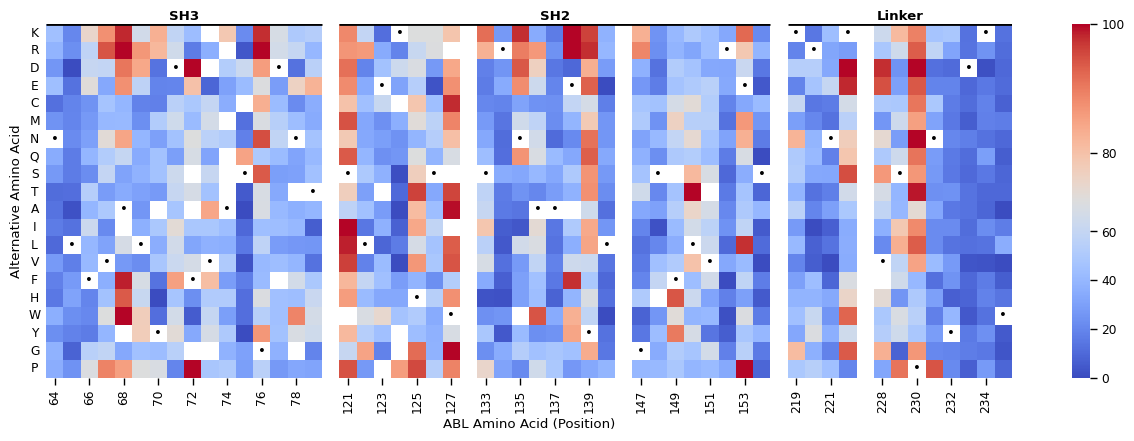

In [94]:
rcParams['figure.figsize'] = 12.72,4.5
WT_map = sns.heatmap(Asc_WT_PV_SHSH2, cmap=cmap_white, annot=Asc_WT_PV_SHSH2.replace(1,'•'),
                     fmt='',annot_kws={'color':'black', 'ha':"center"}, cbar=False, xticklabels=False)
DMS_heatmap2 = sns.heatmap(Asc_DMS_PV_SHSH2,cmap=cmap_coolwarm, norm=mcolors.TwoSlopeNorm(vcenter = SD2, vmin=0, vmax=100))
DMS_heatmap2.set(xticks = SH3SH2_ticks, xticklabels=SH3SH2_tick_labels)
DMS_heatmap2.set_yticklabels(labels=DMS_heatmap2.get_yticklabels(), rotation=0, ha="center")
DMS_heatmap2.set(ylabel='Alternative Amino Acid', xlabel='ABL Amino Acid (Position)')
DMS_heatmap2.tick_params(left=False)
DMS_heatmap2.text(8, -0.25, 'SH3', fontweight='bold', horizontalalignment='center')
DMS_heatmap2.hlines(0, 0, 16, colors='black', linestyles='solid', linewidth=2)
DMS_heatmap2.text(29.5, -0.25, 'SH2',fontweight='bold', horizontalalignment='center')
DMS_heatmap2.hlines(0, 17, 17+25, colors='black', linestyles='solid', linewidth=2)
DMS_heatmap2.text(49.5, -0.25, 'Linker', fontweight='bold', horizontalalignment='center')
DMS_heatmap2.hlines(0, 17+25+1, 17+25+14, colors='black', linestyles='solid', linewidth=2)
plt.tight_layout()
DMS_heatmap2.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/DMS Screen/Norm_DMS250810_SH3SH2.pdf', dpi=1200, transparent=True)

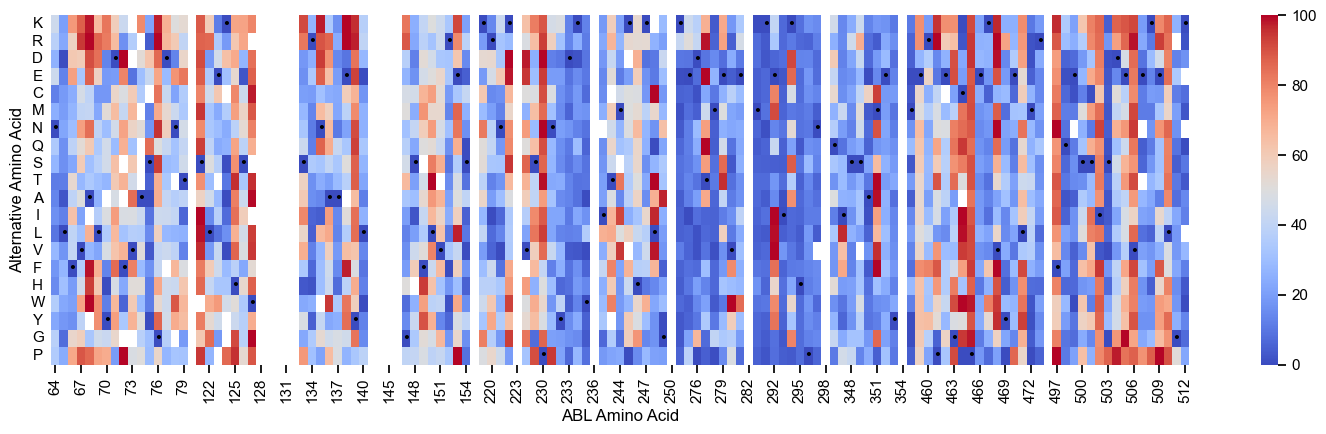

In [164]:
rcParams['figure.figsize'] = 15,4.5
DMS_heatmap = sns.heatmap(Asc_DMS_PV,cmap=cmap_coolwarm, vmin=0, vmax=100,
                         xticklabels=[''])

WT_map = sns.heatmap(Asc_WT_PV, cmap=cmap_coolwarm, annot=Asc_WT_PV.replace(1,'•'),
                     fmt='',annot_kws={'color':'black', 'ha':"center"}, cbar=False)
DMS_heatmap.set_yticklabels(labels=DMS_heatmap.get_yticklabels(), rotation=0, ha="center")
DMS_heatmap.set(ylabel='Alternative Amino Acid', xlabel='ABL Amino Acid')
DMS_heatmap.tick_params(left=False)
plt.tight_layout()

#DMS_heatmap.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/DMS Screen/Reds Cbar2.pdf', dpi=600, transparent=True)

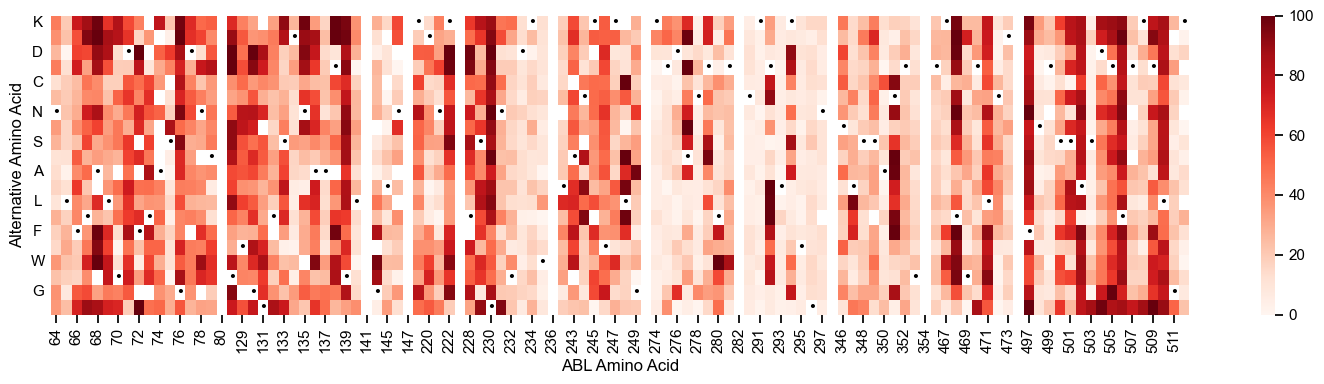

In [69]:
rcParams['figure.figsize'] = 15,4
DMS_heatmap = sns.heatmap(Asc_DMS_PV,cmap='Reds', vmin=0, vmax=100,
                         xticklabels=[''])

WT_map = sns.heatmap(Asc_WT_PV, cmap=cmap_white, annot=Asc_WT_PV.replace(1,'•'),
                     fmt='',annot_kws={'color':'black', 'ha':"center"}, cbar=False)
DMS_heatmap.set_yticklabels(labels=DMS_heatmap.get_yticklabels(), rotation=0, ha="center")
DMS_heatmap.set(ylabel='Alternative Amino Acid', xlabel='ABL Amino Acid')
DMS_heatmap.tick_params(left=False)
plt.tight_layout()
DMS_heatmap.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/DMS Screen/Reds Cbar.pdf', dpi=600, transparent=True)

In [ ]:
spacer_col = [64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77, 78,  79, 80,
              121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
              144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 156,
              219, 220, 221, 222, 223,
              228, 229, 230, 231, 232, 233, 234, 235, 236, 
              242, 243, 244, 245, 246, 247, 248, 249, 250, 
              274, 275, 276, 277, 278, 279, 280, 281, 282,
              290, 291, 292, 293, 294, 295, 296, 297,298, 
              346, 347, 348, 349, 350, 351, 352, 353, 354, 
              458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474,
              497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512]

In [124]:
len([64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77, 78,  79, 80,
              121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
              144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 156,
              219, 220, 221, 222, 223,
              228, 229, 230, 231, 232, 233, 234, 235, 236,])

64

In [134]:
Asc_WT_PV

Position,64,65,66,67,68,69,70,71,72,73,...,503,504,505,506,507,508,509,510,511,512
Mutation,,,,,,,,,,,,,,,,,,,,,
K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0
R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN
C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


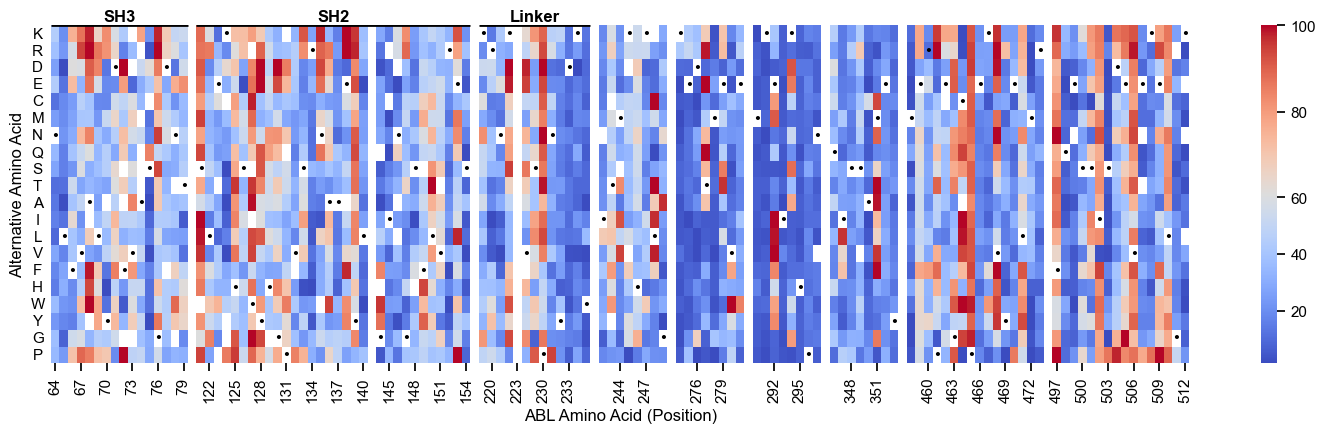

In [130]:
rcParams['figure.figsize'] = 15,4.5
WT_map = sns.heatmap(Asc_WT_PV, cmap=cmap_white, annot=Asc_WT_PV.replace(1,'•'),
                     fmt='',annot_kws={'color':'black', 'ha':"center"}, cbar=False, xticklabels=False)
DMS_heatmap = sns.heatmap(Asc_DMS_PV,cmap=cmap_coolwarm, norm=mcolors.TwoSlopeNorm(vcenter = 61, vmin=1.5, vmax=100))
DMS_heatmap.set(xticks = custom_xticks, xticklabels=custom_xlabels)
DMS_heatmap.set_yticklabels(labels=DMS_heatmap.get_yticklabels(), rotation=0, ha="center")
DMS_heatmap.set(ylabel='Alternative Amino Acid', xlabel='ABL Amino Acid (Position)')
DMS_heatmap.tick_params(left=False)
DMS_heatmap.text(8, -0.25, 'SH3', fontweight='bold', horizontalalignment='center')
DMS_heatmap.hlines(0, 0, 16, colors='black', linestyles='solid', linewidth=2)
DMS_heatmap.text(33, -0.25, 'SH2',fontweight='bold', horizontalalignment='center')
DMS_heatmap.hlines(0, 17, 49, colors='black', linestyles='solid', linewidth=2)
DMS_heatmap.text(56.5, -0.25, 'Linker', fontweight='bold', horizontalalignment='center')
DMS_heatmap.hlines(0, 50, 63, colors='black', linestyles='solid', linewidth=2)
#DMS_heatmap.text(75, -0.25, 'Kinase', fontweight='bold')
#DMS_heatmap.hlines(0, 49, 110, colors='black', linestyles='solid', linewidth=2)
plt.tight_layout()
#DMS_heatmap.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/DMS Screen/Norm_DMS241210v3.pdf', dpi=1200, transparent=True)

<Axes: xlabel='Position', ylabel='Mutation'>

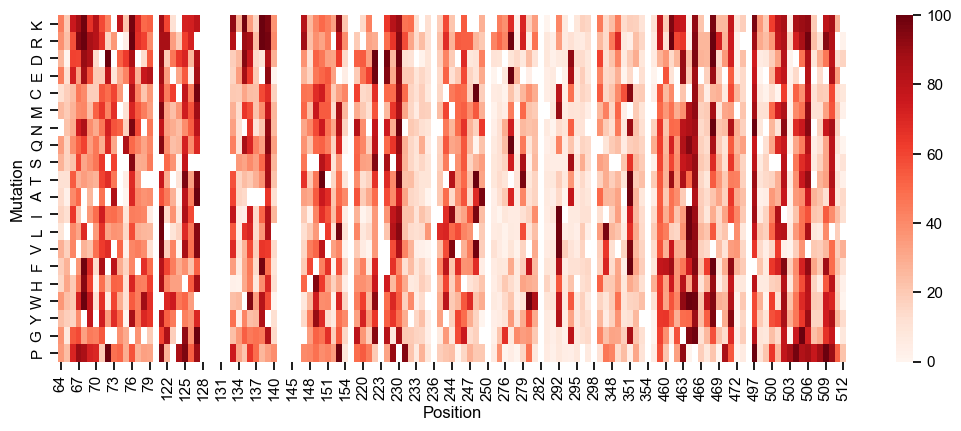

In [295]:
sns.heatmap(Asc_DMS_PV,cmap= sns.color_palette("Reds",101),  vmin=0, vmax=100)

In [114]:
print(xtick_normal_text)

['64', '67', '70', '73', '76', '79', '122', '125', '128', '131', '134', '137', '140', '145', '148', '151', '154', '220', '223', '230', '233', '236', '244', '247', '250', '276', '279', '282', '292', '295', '298', '348', '351', '354', '460', '463', '466', '469', '472', '497', '500', '503', '506', '509', '512']


## Determine the frequency of potent reisstance mutations

In [276]:
Asc_DMS2.loc[Asc_DMS2['Mut'].isin(known_resistance_mutants), ['Mut', 'Min_Max']]

Cond_Rep,Mut,Min_Max
996,L248V,98.085260
1460,M351T,101.361372
1962,I502L,82.878528
1346,K294E,85.791570
1651,P465S,90.453168
1039,M244V,94.410510
1879,V468F,100.284810


In [96]:
Resistance_Cutoff =  80 # mean of resistent population
Asc_DMS3['Resist'] = Asc_DMS3['Min_Max'] > Resistance_Cutoff
Resist_Position = Asc_DMS3.dropna()[['Position', 'Resist']].groupby('Position').agg('mean')
pos_resist = Resist_Position.reset_index().values.tolist()

pos_red = []
for pos, resist in Resist_Position.reset_index().values.tolist():
    pos_red.append([int(pos), sns.color_palette("Reds", 101)[round(resist*100)]])

In [97]:
for i, color in enumerate(sns.color_palette("Reds", 101)):
    print('set_color red' + str(i) + ' = ' + str(list(color)))

set_color red0 = [0.9997539407920031, 0.9556170703575548, 0.9337946943483275]
set_color red1 = [0.9993848519800077, 0.9478662053056517, 0.922722029988466]
set_color red2 = [0.9991387927720108, 0.9426989619377163, 0.9153402537485582]
set_color red3 = [0.9987697039600154, 0.9349480968858132, 0.9042675893886967]
set_color red4 = [0.9985236447520185, 0.9297808535178778, 0.8968858131487889]
set_color red5 = [0.9981545559400231, 0.9220299884659746, 0.8858131487889274]
set_color red6 = [0.9979084967320262, 0.9168627450980392, 0.8784313725490196]
set_color red7 = [0.9975394079200308, 0.9091118800461361, 0.867358708189158]
set_color red8 = [0.9972933487120338, 0.9039446366782007, 0.8599769319492503]
set_color red9 = [0.9969242599000384, 0.8961937716262975, 0.8489042675893886]
set_color red10 = [0.9966782006920415, 0.8910265282583621, 0.841522491349481]
set_color red11 = [0.9963091118800461, 0.883275663206459, 0.8304498269896193]
set_color red12 = [0.9960476739715494, 0.8778623606305267, 0.82277

In [98]:
for pos, resist in Resist_Position.reset_index().values.tolist():
    print('color red' + str(round(resist*100)) + ' , resi ' + str(int(pos)))

color red0 , resi 64
color red0 , resi 65
color red0 , resi 66
color red16 , resi 67
color red53 , resi 68
color red11 , resi 69
color red11 , resi 70
color red5 , resi 71
color red12 , resi 72
color red12 , resi 73
color red0 , resi 74
color red6 , resi 75
color red37 , resi 76
color red0 , resi 77
color red6 , resi 78
color red5 , resi 79
color red6 , resi 120
color red72 , resi 121
color red11 , resi 122
color red0 , resi 123
color red6 , resi 124
color red32 , resi 125
color red0 , resi 126
color red75 , resi 127
color red11 , resi 133
color red0 , resi 134
color red28 , resi 135
color red11 , resi 136
color red0 , resi 137
color red28 , resi 138
color red58 , resi 139
color red0 , resi 140
color red11 , resi 147
color red0 , resi 148
color red11 , resi 149
color red11 , resi 150
color red0 , resi 151
color red0 , resi 152
color red26 , resi 153
color red0 , resi 154
color red11 , resi 219
color red0 , resi 220
color red0 , resi 221
color red26 , resi 222
color red22 , resi 228
col

In [99]:
for pos, resist in Resist_Position.loc[Resist_Position['Resist']>0.5].reset_index().values.tolist():

Cond_Rep,Resist
Position,
64,0.000000
65,0.000000
66,0.000000
67,0.157895
68,0.529412
...,...
508,0.052632
509,0.157895
510,0.578947


In [103]:
QuarterHit = []
for pos, resist in Resist_Position.loc[Resist_Position['Resist']>0.25].reset_index().values.tolist():
    QuarterHit.append(int(pos))

"+".join(map(str, QuarterHit))

'68+76+121+125+127+135+138+139+153+222+230+292+351+463+464+465+468+497+502+506+510'

In [ ]:
show spheres, (resi 68+76+121+125+127+135+138+139+153+222+230+292+351+463+464+465+468+497+502+506+510) and name CA


In [ ]:
set sphere_scale, 1.5, (resi 68+76+121+125+127+135+138+139+153+222+230+292+351+463+464+465+468+497+502+506+510)) and name CA